In [13]:
import os
import cv2
import numpy as np

healthy_path = r"C:\Users\muthu\Desktop\Cotton_Bollworm_Project\dataset\train\healthy"

errors = []

for img_name in os.listdir(healthy_path):
    img_path = os.path.join(healthy_path, img_name)

    img = cv2.imread(img_path)
    if img is None:
        continue

    img = cv2.resize(img, (128,128))
    img = img.astype("float32") / 255.0
    img = np.expand_dims(img, axis=0)

    reconstructed = autoencoder.predict(img, verbose=0)
    error = np.mean((img - reconstructed) ** 2)

    errors.append(error)

# Compute threshold
mean_error = np.mean(errors)
std_error = np.std(errors)

THRESHOLD = mean_error + 1 * std_error 

print("Mean Error:", mean_error)
print("Std Error:", std_error)
print("Final Threshold:", THRESHOLD)

Mean Error: 0.008987701
Std Error: 0.005571311
Final Threshold: 0.014559011440724134


In [19]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model

# ===============================================
# LOAD MODEL
# ===============================================

print("Loading Models...")

autoencoder = load_model(
    r"C:\Users\muthu\Desktop\Cotton_Bollworm_Project\autoencoder_model\bollworm_autoencoder.h5",
    compile=False
)

print("Models Loaded Successfully ✔")

# ===============================================
# PREPROCESS FUNCTION
# ===============================================

def preprocess_autoencoder(img):
    img = cv2.resize(img, (128,128))
    img = img.astype("float32") / 255.0
    return np.expand_dims(img, axis=0)

# ===============================================
# AUTOENCODER TEST FUNCTION
# ===============================================

def test_autoencoder(image_path):

    frame = cv2.imread(image_path)

    if frame is None:
        print("❌ Image not found")
        return

    # Preprocess
    ae_input = preprocess_autoencoder(frame)

    # Reconstruction
    reconstructed = autoencoder.predict(ae_input, verbose=0)

    # Error calculation
    error = np.mean((ae_input - reconstructed) ** 2)

    # Threshold (adjust if needed)
    THRESHOLD = 0.0145

    status = "NORMAL" if error < THRESHOLD else "ANOMALY"

    # ===============================================
    # OUTPUT (YOUR REQUIRED FORMAT)
    # ===============================================

    print("\n========== AUTOENCODER ==========")
    print("Status :", status)
    print("Reconstruction Error :", round(error, 5))


# ===============================================
# RUN TEST
# ===============================================

test_autoencoder(r"C:\Users\muthu\Desktop\Smart_cotton_AI\test_images\aphids4.jpg")

Loading Models...
Models Loaded Successfully ✔

========== AUTOENCODER ==========
Status : ANOMALY
Reconstruction Error : 0.01525


In [9]:
import cv2
import numpy as np
from tensorflow.keras.models import load_model

# Load model
cnn = load_model(r"cotton_disease_mobilenet.h5")

# Class labels (same order as training)
class_names = [
'aphids',
'army_worm',
'bacterial_blight',
'fungal_disease',
'healthy',
'powdery_mildew'
]

# Load test image
img_path = r"C:\Users\muthu\Desktop\Cotton_Bollworm_Project\cnn_data_original\train\army_worm\16.jpg"

img = cv2.imread(img_path)

# Preprocess
img = cv2.resize(img,(224,224))
img = img.astype("float32")/255
img = np.expand_dims(img,axis=0)

# Predict
pred = cnn.predict(img)[0]

print("Prediction vector:", pred)

idx = np.argmax(pred)

print("Predicted class:", class_names[idx])
print("Confidence:", pred[idx])

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Prediction vector: [5.6482041e-03 9.7179013e-01 1.5264890e-02 1.4335738e-03 4.9598129e-03
 9.0336398e-04]
Predicted class: army_worm
Confidence: 0.97179013


Loading Models...
Models Loaded Successfully ✔

========== AUTOENCODER ==========
Status : ANOMALY
Reconstruction Error : 0.01486

========== CNN CLASSIFICATION ==========
Predicted Class : army_worm
Confidence : 1.0


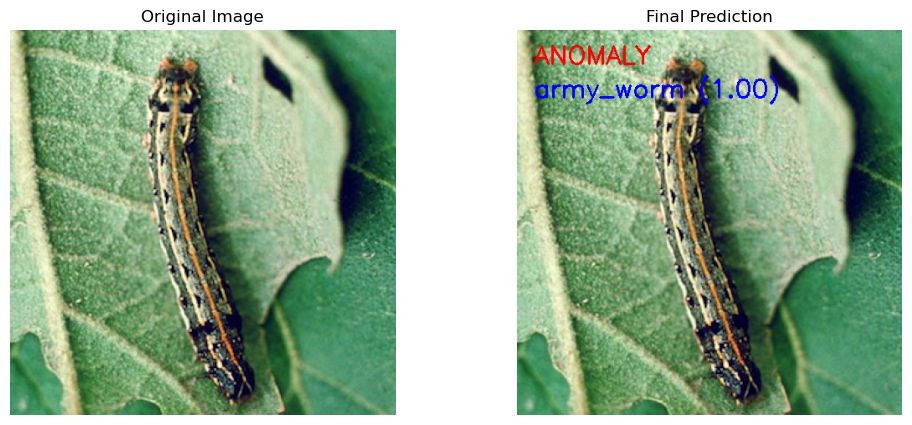

In [15]:
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# ===============================================
# LOAD MODELS
# ===============================================

print("Loading Models...")

autoencoder = load_model(
    r"C:\Users\muthu\Desktop\Cotton_Bollworm_Project\autoencoder_model\bollworm_autoencoder.h5",
    compile=False
)

cnn = load_model("cotton_disease_mobilenet.h5", compile=False)

print("Models Loaded Successfully ✔")

# ===============================================
# CLASS LABELS
# ===============================================

class_names = [
    'aphids',
    'army_worm',
    'bacterial_blight',
    'fungal_disease',
    'healthy',
    'powdery_mildew'
]

# ===============================================
# PREPROCESS FUNCTIONS
# ===============================================

def preprocess_autoencoder(img):
    img = cv2.resize(img, (128,128))
    img = img.astype("float32") / 255.0
    return np.expand_dims(img, axis=0)

def preprocess_cnn(img):
    img = cv2.resize(img, (224,224))
    img = img.astype("float32") / 255.0
    return np.expand_dims(img, axis=0)

# ===============================================
# PIPELINE FUNCTION
# ===============================================

def run_pipeline(image_path):

    frame = cv2.imread(image_path)

    if frame is None:
        print("❌ Image not found")
        return

    original = frame.copy()

    # ---------- AUTOENCODER ----------
    ae_input = preprocess_autoencoder(frame)
    reconstructed = autoencoder.predict(ae_input, verbose=0)

    error = np.mean((ae_input - reconstructed) ** 2)
    THRESHOLD = 0.0145

    status = "NORMAL" if error < THRESHOLD else "ANOMALY"

    print("\n========== AUTOENCODER ==========")
    print("Status :", status)
    print("Reconstruction Error :", round(error, 5))

    # ---------- CNN CLASSIFICATION ----------
    print("\n========== CNN CLASSIFICATION ==========")

    cnn_input = preprocess_cnn(frame)
    preds = cnn.predict(cnn_input, verbose=0)[0]

    idx = np.argmax(preds)
    label = class_names[idx]
    confidence = preds[idx]

    print("Predicted Class :", label)
    print("Confidence :", round(confidence, 4))

    # ---------- DISPLAY ----------
    annotated = original.copy()

    # Status text
    cv2.putText(
        annotated,
        f"{status}",
        (20,40),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (0,255,0) if status=="NORMAL" else (0,0,255),
        2
    )

    # Prediction text
    cv2.putText(
        annotated,
        f"{label} ({confidence:.2f})",
        (20,80),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (255,0,0),
        2
    )

    # ---------- VISUAL OUTPUT ----------
    fig = plt.figure(figsize=(12,5))

    ax1 = fig.add_subplot(1,2,1)
    ax1.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    ax1.set_title("Original Image")
    ax1.axis("off")

    ax2 = fig.add_subplot(1,2,2)
    ax2.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    ax2.set_title("Final Prediction")
    ax2.axis("off")

    plt.show()

# ===============================================
# RUN
# ===============================================

run_pipeline(r"C:\Users\muthu\Desktop\Smart_cotton_AI\test_images\army4.jpg")